# Credit Risk Prediction Using Decisiom Trees and Random Forests

## Objective: Predict whether a customer will default on credit and compare baseline and optimized Decision Tree and Random Forest models.

# STEP 1 - DOWNLOAD THE DATASET

#### Import Pandas module
#### Load the read data in a datafram called df

In [75]:
import pandas as pd

file_path = "datasets/credit-risk-dataset/credit_risk_dataset.csv"

df = pd.read_csv(file_path)

# STEP 2 - INSPECTING THE FIRST ROWS

#### df.head() gives me the first 5 rows

In [76]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# STEP 3 - IDENTIFYING THE TARGET

#### The target Y will be Loan Status because that is what we are trying to predict, whether the customer will default or not

# STEP 4 - CHECK THE DATASET STRUCTURE

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


#### The two columns with missing values are person_emp_length and and loan_int_rate. I can tell because the count is not the total of 32581 like the others

In [78]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

#### df.isnull().sum checks every column that has a null value, tallies them and gives me the count

In [79]:
person_emp_length_percentage = (df["person_emp_length"].isnull().sum() / len(df)) * 100
print(person_emp_length_percentage)

2.7469997851508547


In [80]:
loan_int_rate = (df["loan_int_rate"].isnull().sum() / len(df)) * 100
print(loan_int_rate)

9.563856235229121


#### person_emp_length_percentage and loan_int_rate let us see what percentage of data is missing in each column where null values are reported. 
#### If they are insignificant. we could do away with the data. But if they are significant we may need another way to mak eup fo rthe loss data. 

#### person_emp_length → 2.75% 
#### missing loan_int_rate → 9.56% 

#### Before we decide how to fill them, we should understand the values in those two numeric columns.

In [81]:
df['person_emp_length'].describe()

count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

In [82]:
df['loan_int_rate'].describe()

count    29465.000000
mean        11.011695
std          3.240459
min          5.420000
25%          7.900000
50%         10.990000
75%         13.470000
max         23.220000
Name: loan_int_rate, dtype: float64

We use <b>describe</b> to analyze the column. <b>Decsribe</b> tells me the mean, median, count, max lows and any other weird data I can catch<br>
In person_emp_length, the max years of 1234 is unreasonable. Thehe value 123 years of employment is almost certainly suspicious and could distort the model if left untreated.<br>
In that case we can check the person's age to see. And we can see the person who has worked for 123 is 22 years. That is quite impossible.<br>
One check we could apply is to check that someone's age is greater than their employment years <br?

In [83]:
df[df['person_emp_length'] > df['person_age']]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


### Data Quality Observation: Employment Length

The comparison identified **2 rows** where employment length is greater than the customer's age:

- **Row 0:** age = 22, employment length = 123
- **Row 210:** age = 21, employment length = 123

An employment length of `123` years is not realistic, so it should be treated as an <span style="color:red"><b>invalid value</b></span> in `person_emp_length`.

### Decision

We will **keep both customer records** because their other information may still be useful. Instead, we will:

1. Convert `123` to a missing value.
2. Handle it together with the other missing employment-length values.
3. Fill the missing values using the **median** employment length.

The median is preferred because the extreme value `123` pulls the **mean** upward, while the median is more resistant to outliers. This gives us a more realistic replacement value.

In [84]:
import numpy as np

df["person_emp_length"] = df["person_emp_length"].replace(123, np.nan)

In [85]:
df["person_emp_length"].isnull().sum()

np.int64(897)

### Missing-Value Correction

At **Cell 7**, `person_emp_length` had **895 null values**.

After replacing the two unrealistic `123` values with `NaN`, the number of null values increased to **897**:

- **895 original null values**
- **+ 2 invalid employment-length values**
- **= 897 total null values**

This confirms that the invalid values were successfully identified and converted to missing values. The `person_emp_length` column is now ready for **median imputation**.

<span style="color:red"><b>Conclusion:</b> The data has been cleaned without deleting the customer records.</span>

# Restored Steps 5-8: Encoding, Splitting, and Baseline Model

## Step 5: Encode Categorical Features

Scikit-learn models require numeric inputs. We therefore used **ordinal encoding** for `loan_grade`, **binary encoding** for `cb_person_default_on_file`, and **one-hot encoding** for the unordered categories `person_home_ownership` and `loan_intent`.

Missing numeric values were filled with their medians: **4 years** for `person_emp_length` and **10.99%** for `loan_int_rate`. The invalid employment-length value `123` was treated as missing before imputation.

## Step 6: Separate Features and Target

- **`X`** contains the predictor features.
- **`y`** contains `loan_status`, the answer the model must predict.

`loan_status` was removed from `X` to prevent **data leakage**.

## Step 7: Create Training and Testing Sets

The target contains **25,473 non-defaults (78.18%)** and **7,108 defaults (21.82%)**, so the classes are imbalanced. We used a **30% test split**, `stratify=y` to preserve the class ratio, and `random_state=42` to make the split reproducible.

The resulting datasets are `X_train`, `X_test`, `y_train`, and `y_test`.

## Step 8: Baseline Decision Tree

The baseline model measures performance before optimization. We created a new `DecisionTreeClassifier`, trained it with `fit(X_train, y_train)`, and generated predictions with `predict(X_test)`. Its performance will later be compared with the tuned model from `GridSearchCV`.

<span style="color:red"><b>Conclusion:</b> The data has been cleaned, encoded, split correctly, and used to train a baseline Decision Tree ready for evaluation.</span>

In [86]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Complete the numeric cleaning and encoding.
median = df["person_emp_length"].median()
df["person_emp_length"] = df["person_emp_length"].fillna(median)

median = df["loan_int_rate"].median()
df["loan_int_rate"] = df["loan_int_rate"].fillna(median)

grade_mapping = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
df["loan_grade_encoded"] = df["loan_grade"].map(grade_mapping)

default_on_file_mapping = {"N": 0, "Y": 1}
df["cb_person_default_encoded"] = df["cb_person_default_on_file"].map(default_on_file_mapping)

df = pd.get_dummies(
    df,
    columns=["person_home_ownership", "loan_intent"],
    drop_first=True,
    dtype=int
)

df = df.drop(columns=["loan_grade", "cb_person_default_on_file"])

y = df["loan_status"]
x = df.drop(columns=["loan_status"])

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

dt_baseline = DecisionTreeClassifier()
dt_baseline.fit(X_train, y_train)
y_pred_dt = dt_baseline.predict(X_test)

# STEP 9 - EVALUATE DATA WITH CONFUSION MATRIX, CLASSIFICATION< ACCURACY

### ACCURACY
actual answers<br>
vs<br>
predicted answers<br>

In [91]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred_dt)

0.887468030690537

### CONFUSION MATRIX

In [92]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_dt)

array([[7026,  616],
       [ 484, 1649]])

### Confusion Matrix: Actual vs. Predicted

|  | **Predicted 0** | **Predicted 1** |
|---|---:|---:|
| **Actual 0** | **7,045** | **597** |
| **Actual 1** | **480** | **1,653** |

### Confusion Matrix Summary

The confusion matrix shows how the baseline Decision Tree's predictions compare with the actual loan-status values.

### Memory Shortcut
Precision hates FP<br>
Recall hates FN<br>

#### Actual vs. Predicted Values

|  | **Predicted 0** | **Predicted 1** |
|---|---:|---:|
| **Actual 0** | **7,045** | **597** |
| **Actual 1** | **480** | **1,653** |

#### Interpretation

| Outcome | Meaning | Count |
|---|---|---:|
| **True Negative (TN)** | Correctly predicted non-default | **7,045** |
| **False Positive (FP)** | Predicted default, but the customer did not default | **597** |
| **False Negative (FN)** | Predicted non-default, but the customer defaulted | **480** |
| **True Positive (TP)** | Correctly predicted default | **1,653** |

<span style="color:red"><b>Key point:</b> False negatives are especially important in credit-risk prediction because they represent customers who defaulted but were predicted as non-defaults.</span>

### CLASSIFICATION REPORT

In [94]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7642
           1       0.73      0.77      0.75      2133

    accuracy                           0.89      9775
   macro avg       0.83      0.85      0.84      9775
weighted avg       0.89      0.89      0.89      9775



### Classification Report Summary

The classification report evaluates how well the baseline Decision Tree predicts each loan-status class.

#### Default Class (`1`)

- **Support = 2,133:** There were **2,133 actual defaulters** in the test set.
- **Recall = 0.77:** Of the customers who actually defaulted, the model correctly identified approximately **77%**.
- **Precision = 0.73:** Of the customers the model predicted would default, approximately **73% actually defaulted**.
- **F1-score = 0.75:** The model has a **fairly good balance** between reliably predicting defaults and identifying actual defaulters.

#### Overall Results

- **Accuracy = 0.89:** The model made correct predictions for approximately **89%** of all test customers.
- The model performed better on class `0` than on class `1`, which is expected because the dataset contains more non-defaults than defaults.

<span style="color:red"><b>Conclusion:</b> The baseline Decision Tree identifies most actual defaulters, but some defaults are still missed. Recall, precision, and F1-score should therefore all be considered rather than relying on accuracy alone.</span>

# STEP 10 - BASELINE RANDOM FOREST

In [96]:
from sklearn.ensemble import RandomForestClassifier
rf_baseline = RandomForestClassifier()
rf_baseline.fit(X_train, y_train)
y_pred_rf = rf_baseline.predict(X_test)

In [97]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred_rf)

0.9348337595907928

It was 89% in decision tree<br>
It is 93% in Random Forest<br>

In [99]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_rf)

array([[7589,   53],
       [ 584, 1549]])

### Confusion Matrix: Actual vs. Predicted for DECISION TREE

|  | **Predicted 0** | **Predicted 1** |
|---|---:|---:|
| **Actual 0** | **7,045** | **597** |
| **Actual 1** | **480** | **1,653** |<br>

### Confusion Matrix: Actual vs. Predicted RANDOM FOREST

|  | **Predicted 0** | **Predicted 1** |
|---|---:|---:|
| **Actual 0** | **7,589** | **53** |
| **Actual 1** | **584** | **1,549** |

In [102]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      7642
           1       0.97      0.73      0.83      2133

    accuracy                           0.93      9775
   macro avg       0.95      0.86      0.89      9775
weighted avg       0.94      0.93      0.93      9775



### Baseline Evaluation: Why Recall Matters

A **false negative** occurs when the model predicts:

> **"This customer will not default,"** but the customer actually **does default**.

For a lender, this could mean approving a risky loan and losing money. Because false negatives are costly, overall accuracy should not be the only metric used to judge the models.

### Comparing the Baseline Models

The baseline Random Forest achieved higher overall accuracy than the Decision Tree:

- **Decision Tree accuracy:** 89%
- **Random Forest accuracy:** 93%

However, the Random Forest's ability to catch actual defaulters must also be considered. The classification report gives us four important metrics:

- **Accuracy:** The percentage of all predictions that were correct.
- **Precision:** Of the customers predicted to default, how many actually defaulted?
- **Recall:** Of all customers who actually defaulted, how many did the model successfully identify?
- **F1-score:** A balance between precision and recall.

### Most Important Metric for This Project

The metric we should pay particularly close attention to is **recall**.

For this credit-risk problem:

> **Higher recall** means **fewer false negatives**, which means **fewer risky customers are missed**.

The baseline Decision Tree achieved a default recall of **0.77**, while the Random Forest achieved **0.73**. Therefore, the Random Forest's higher accuracy does not automatically make it the better model for this business problem. The cost of missed defaulters must be considered alongside precision, F1-score, and accuracy.

<span style="color:red"><b>Conclusion:</b> Baseline evaluation is complete for both models. The next stage is to tune the models and compare whether optimization improves their performance, especially their ability to catch actual defaulters.</span>

# STEP 11 - SINGLE DECISION TREE - 5 FOLD CROSS VALIDATION HYPERPARAMETER TUNING

In [107]:
from sklearn.model_selection import GridSearchCV
dt_param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}
dt_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy"
)

estimator<br>
→ the model we want to tune<br>

param_grid<br>
→ the 72 combinations we just created<br>

cv=5<br>
→ 5-fold cross-validation<br>

scoring="accuracy"<br>
→ choose the combination with the best average accuracy<br>

In [109]:
dt_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"

In [110]:
dt_grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 5}

In [111]:
dt_optimized = dt_grid_search.best_estimator_

In [112]:
y_pred_dt_optimized = dt_optimized.predict(X_test)

In [113]:
accuracy_score(y_test, y_pred_dt_optimized)

0.929616368286445

Baseline Decision Tree accuracy  ≈ 88.98%<br>
Optimized Decision Tree accuracy ≈ 92.96%<br>

So tuning improved accuracy by about:<br>
92.96% - 88.98% ≈ 3.98 percentage points<br>

In [114]:
confusion_matrix(y_test, y_pred_dt_optimized)

array([[7574,   68],
       [ 620, 1513]])

In [115]:
print(classification_report(y_test, y_pred_dt_optimized))

              precision    recall  f1-score   support

           0       0.92      0.99      0.96      7642
           1       0.96      0.71      0.81      2133

    accuracy                           0.93      9775
   macro avg       0.94      0.85      0.89      9775
weighted avg       0.93      0.93      0.93      9775



| Metric    | Baseline Decision Tree | Optimized Decision Tree |
| --------- | ---------------------: | ----------------------: |
| Accuracy  |                   0.89 |                **0.93** |
| Precision |                   0.73 |                **0.96** |
| Recall    |               **0.77** |                    0.71 |
| F1-score  |                   0.75 |                **0.81** |


So the optimized tree is much more trustworthy when it predicts “default”, but it is also missing more actual defaulters.

### Step 11 Summary: Hyperparameter Tuning

#### What Is Hyperparameter Tuning?

Hyperparameter tuning finds the **best settings for a model**. It does not directly choose which features to use. Instead, it tests different configuration choices before training the final model.

For the Decision Tree, we tested:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `criterion`

For a Random Forest, common settings include:

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

#### Five-Fold Cross-Validation

With **5-fold cross-validation**, the training data is divided into five parts. In each round, four folds are used for training and one fold is used for validation:

| Round | Training Folds | Validation Fold |
|---|---|---|
| 1 | 2, 3, 4, 5 | 1 |
| 2 | 1, 3, 4, 5 | 2 |
| 3 | 1, 2, 4, 5 | 3 |
| 4 | 1, 2, 3, 5 | 4 |
| 5 | 1, 2, 3, 4 | 5 |

Each fold is used once as validation data. The results are combined to estimate how well each hyperparameter combination performs.

#### Important Decision-Tree Settings

- **`max_depth`** controls the maximum number of tree levels. For example, `max_depth=3` prevents the tree from growing beyond three levels. A very small depth may underfit, while an unrestricted depth may overfit.
- **`min_samples_split`** controls the minimum number of samples a node needs before it may be split. With `min_samples_split=2`, a node needs at least two samples to attempt another split.
- **`min_samples_leaf`** controls the minimum number of samples that must remain in each child leaf after a split. With `min_samples_leaf=4`, every final leaf must contain at least four samples.
- **`criterion`** tells the tree how to judge the quality of a split. **Gini** and **entropy** measure how mixed the classes are in a node.

#### Results of Tuning

The optimized Decision Tree improved accuracy from approximately **88.98%** to **92.96%**, an improvement of about **3.98 percentage points**. It also reduced false positives from **597 to 68**.

However, false negatives increased from **480 to 620**. This means the optimized tree missed more actual defaulters, so its default recall decreased:

- **Baseline recall:** 0.77
- **Optimized recall:** 0.71

<span style="color:red"><b>Conclusion:</b> The optimized tree is more accurate and more precise when it predicts default, but the baseline tree is preferable when the bank's main priority is catching as many actual defaulters as possible. Model selection should therefore consider recall, precision, F1-score, and accuracy together.</span>

# STEP 12 - RANDOM DECISION TREE - HYPERPARAMTER TUNING

In [117]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [118]:
rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy"
)

In [119]:
rf_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

In [120]:
rf_grid_search.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'n_estimators': 200}

In [121]:
rf_optimized = rf_grid_search.best_estimator_

In [122]:
y_pred_rf_optimized = rf_optimized.predict(X_test)

In [123]:
accuracy_score(y_test, y_pred_rf_optimized)

0.9342199488491049

In [124]:
confusion_matrix(y_test, y_pred_rf_optimized)

array([[7593,   49],
       [ 594, 1539]])

In [125]:
print(classification_report(y_test, y_pred_rf_optimized))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      7642
           1       0.97      0.72      0.83      2133

    accuracy                           0.93      9775
   macro avg       0.95      0.86      0.89      9775
weighted avg       0.94      0.93      0.93      9775



| Metric          | Baseline RF | Optimized RF |
| --------------- | ----------: | -----------: |
| Accuracy        |  **93.48%** |       93.42% |
| Precision       |        0.97 |         0.97 |
| Recall          |    **0.73** |         0.72 |
| F1-score        |        0.83 |         0.83 |
| False Positives |          53 |       **49** |
| False Negatives |     **584** |          594 |


### Step 12 Summary: Optimized Random Forest

#### Understanding `n_estimators`

`n_estimators` controls how many individual Decision Trees are built inside the Random Forest:

- `n_estimators = 50` builds **50 trees**.
- `n_estimators = 200` builds **200 trees**.

The trees combine their predictions to produce the Random Forest's final result.

#### Best Hyperparameters

Using **5-fold cross-validation** with `accuracy` scoring, GridSearchCV selected:

- **`n_estimators = 200`**
- **`max_depth = None`**, meaning no fixed maximum depth
- **`min_samples_split = 10`**
- **`min_samples_leaf = 1`**

These settings performed best during cross-validation according to average accuracy.

#### Baseline vs. Optimized Random Forest

| Metric | Baseline RF | Optimized RF | Change |
|---|---:|---:|---:|
| Accuracy | **93.48%** | 93.42% | Slight decrease |
| Precision | 0.97 | 0.97 | No meaningful change |
| Recall | **0.73** | 0.72 | Slight decrease |
| F1-score | 0.83 | 0.83 | No meaningful change |
| False positives | 53 | **49** | Slight improvement |
| False negatives | **584** | 594 | Slight increase |

Tuning reduced false positives from **53 to 49**, but increased false negatives from **584 to 594**. Since false negatives represent actual defaulters who were missed, this increase is important in a credit-risk setting.

#### Main Machine-Learning Lesson

GridSearchCV selects hyperparameters that perform best during cross-validation, but those settings do **not always** improve performance on the final unseen test set. In this case, the optimized Random Forest had slightly lower test accuracy and slightly lower recall than the baseline model.

<span style="color:red"><b>Conclusion:</b> The baseline Random Forest performed slightly better overall on the test set, while the optimized model produced a small reduction in false positives. The final choice should depend on the business priority, especially the cost of missing actual defaulters.</span>

# STEP 13 - FEATURE IMPORTANCE

In [131]:
feature_importance_df = pd.DataFrame({
    "feature": x.columns,
    "importance": rf_baseline.feature_importances_
})
feature_importance_df

,feature,importance
0,person_age,0.046398
1,person_income,0.153686
2,person_emp_length,0.060885
3,loan_amnt,0.075007
4,loan_int_rate,0.112354
5,loan_percent_income,0.220663
6,cb_person_cred_hist_length,0.034818
7,loan_grade_encoded,0.109062
8,cb_person_default_encoded,0.012488
9,person_home_ownership_OTHER,0.001143


In [132]:
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)
feature_importance_df

,feature,importance
5,loan_percent_income,0.220663
1,person_income,0.153686
4,loan_int_rate,0.112354
7,loan_grade_encoded,0.109062
11,person_home_ownership_RENT,0.079991
3,loan_amnt,0.075007
2,person_emp_length,0.060885
0,person_age,0.046398
6,cb_person_cred_hist_length,0.034818
13,loan_intent_HOMEIMPROVEMENT,0.017744


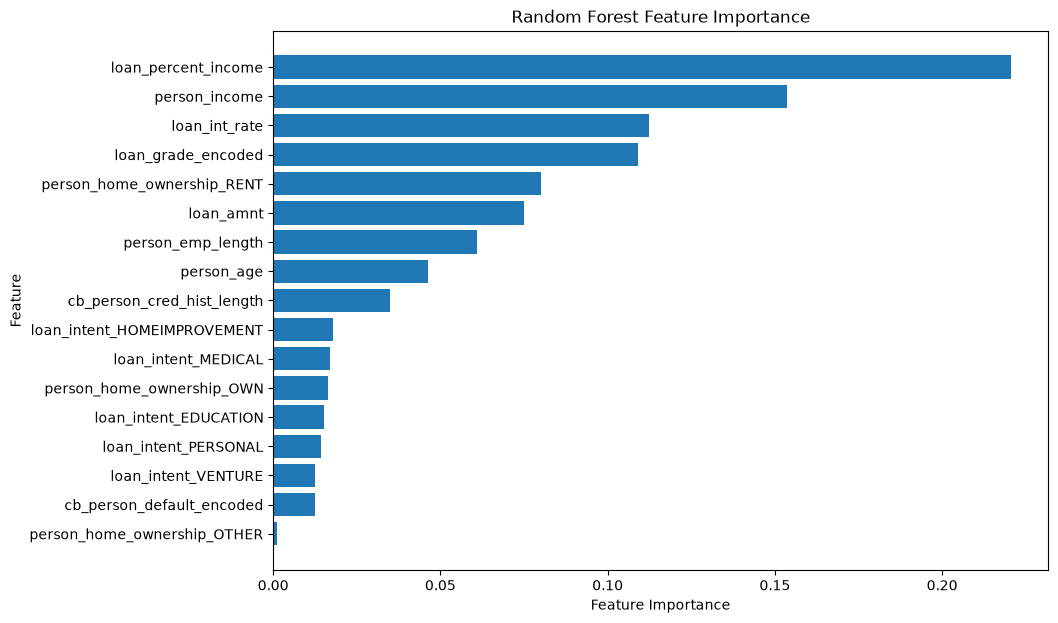

In [133]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.show()

### Step 13 Summary: Random Forest Feature Importance

Feature importance helps us understand which predictor features were most useful to the Random Forest when predicting loan default.

#### What Feature Importance Means

A **higher feature-importance value** does **not** mean that the feature receives a heavier mathematical weight like a regression coefficient. Instead, it means the Random Forest found that feature more useful when making tree splits and reducing impurity.

`loan_percent_income` was not necessarily the first split in every tree. Its high importance means that, across the entire Random Forest, it was one of the most useful features for creating splits that helped separate defaulting and non-defaulting customers.

A more accurate interpretation is:

> `loan_percent_income` is the most important feature in the Random Forest because it contributed the most to useful splits for predicting credit default.

#### What We Did

1. Created `feature_importance_df` using the model's `feature_importances_` values.
2. Matched each importance value with its corresponding feature name from `x.columns`.
3. Sorted the table from the most important feature to the least important feature.
4. Created a horizontal bar chart to make the relative importance of each feature easier to compare.

#### Main Results

The most important features were:

| Rank | Feature | Importance |
|---:|---|---:|
| 1 | `loan_percent_income` | **0.220663** |
| 2 | `person_income` | **0.153686** |
| 3 | `loan_int_rate` | **0.112354** |
| 4 | `loan_grade_encoded` | **0.109062** |
| 5 | `person_home_ownership_RENT` | **0.079991** |

The least important features contributed less to the Random Forest's impurity reduction. Low importance does not automatically mean a feature is useless; it only means that this fitted model relied on it less than the other features.

<span style="color:red"><b>Conclusion:</b> The feature-importance analysis suggests that the proportion of income used for loan payments was the strongest predictor used by this Random Forest. These values describe the model's reliance on features, not causal relationships or regression-style coefficients.</span>